# 1. Estructura del panel

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, Dropdown
import math

PASO 1: Inspeccionar unicamente el nombre de las columnas para corroborar el diccionario

In [65]:
df_preview = pd.read_stata('data/hospitales_msp_presupuestos.dta', iterator=True)
all_columns = df_preview.variable_labels()
column_names_only = list(all_columns.keys())# Solo el nombre (no el key / descripcion)

print(f"Total de columnas: {len(all_columns)}")

def print_columns_grid(columns, n_cols=4):
    """Imprime nombres de columnas en una grilla de n_cols columnas"""
    n_rows = math.ceil(len(columns) / n_cols)
    
    for i in range(n_rows):
        row_items = []
        for j in range(n_cols):
            idx = i + j * n_rows
            if idx < len(columns):
                row_items.append(f"{idx+1:3d}. {columns[idx]:30s}")
        print("  ".join(row_items))

print_columns_grid(column_names_only, n_cols=3)

Total de columnas: 240
  1. date                             81. planning_coordinator_salary     161. pagado_medsupp_               
  2. ruc                              82. planning_coordinator_change     162. prcomprom_medsupp_            
  3. employer_id                      83. admin_director                  163. cod_compl_medical_serv_       
  4. decentralized_entity_merge       84. admin_director_salary           164. dev_compl_medical_serv_       
  5. eod_code                         85. admin_director_change           165. comprom_compl_medical_serv_   
  6. health_center_name               86. finance_director                166. pagado_compl_medical_serv_    
  7. care_level                       87. finance_director_salary         167. prcomprom_compl_medical_serv_ 
  8. service_class                    88. finance_director_change         168. cod_maintain_                 
  9. province_code_alt                89. gender_1                        169. dev_maintain_     

PASO 2: Extraer columnas especificas (identificadas como prioritarias)

In [47]:

identificadores = [
    'date',
    'health_center_name',
    'care_level',
    'service_class',
    'province_name_alt',
    'canton_name1'
]

salud = [
    'hospital_discharges',
    'deaths_total',
    'mortality_rate',
    'medical_visits_firstlevel',
    'prevent_consult_first',
    'morb_consult_first'
]

finanzas = [
    'payment51_bymonth',
    'payment53_bymonth',
    'accrued51_bymonth',
    'accrued53_bymonth',
    'encoded51_bymonth',
    'encoded53_bymonth',
    'pagado_medic_',
    'pagado_medsupp_',
    'codificado_monthly',
    'devengado_monthly',
    'pagado_monthly',
    'cod_medic_',
    'cod_medsupp_'
]

recursos_humanos = [
    'gender_1',
    'gender_2',
    'doctors',
    'spec_doctors',
    'nurses'
]

columns_to_extract = (identificadores + salud + finanzas + recursos_humanos)

df = pd.read_stata('data/hospitales_msp_presupuestos.dta', columns=columns_to_extract)

PASO 3: Estructura de la base

In [48]:

print("="*80)
print("ESTRUCTURA - Resumen")
print("="*80)

print(f"\nTotal de observaciones (filas): {len(df)}")
print(f"Variables totales (columnas): {len(df.columns)}")

# Num de hospitales unicos
n_hospitals = df['health_center_name'].nunique()
print(f"\nHospitales únicos: {n_hospitals}")


# Rango de fechas
df['date'] = pd.to_datetime(df['date'])
print(f"\nRango de fechas: {df['date'].min()} to {df['date'].max()}")
print(f"Total de meses en el conjunto de datos: {df['date'].nunique()}")


# Desde 2015 al 2023, una observación por mes
# ¿Cuantas observaciones deberian haber, dado el num de hospitales?

expected_obs = n_hospitals * df['date'].nunique()
print(f"\nObservaciones esperadas (si está equilibrado): {expected_obs}")
print(f"Observaciones reales: {len(df)}")
print(f"Observaciones faltantes: {expected_obs - len(df)}")
print(f"Integridad del panel: {(len(df) / expected_obs * 100):.1f}%")


# Que hospitales estan completos?

print("\n" + "="*80)
print("OBSERVACIONES POR HOSPITAL")
print("="*80)
obs_per_hospital = df.groupby('health_center_name').size()
print(obs_per_hospital.describe())
print(f"\nHospitales con datos completos: {(obs_per_hospital == obs_per_hospital.max()).sum()}")
print(f"Hospitales con datos incompletos: {(obs_per_hospital < obs_per_hospital.max()).sum()}")

duplicates = df.groupby(['health_center_name', 'date']).size()
duplicates = duplicates[duplicates > 1]
if len(duplicates) > 0:
    print(f"\nADVERTENCIA: Encontrado {len(duplicates)} ¡Duplicados de fechas de hospitalización!")
else:
    print("\n✓ No se encontraron duplicados")

ESTRUCTURA - Resumen

Total de observaciones (filas): 12374
Variables totales (columnas): 30

Hospitales únicos: 121

Rango de fechas: 2015-01-01 00:00:00 to 2023-12-01 00:00:00
Total de meses en el conjunto de datos: 108

Observaciones esperadas (si está equilibrado): 13068
Observaciones reales: 12374
Observaciones faltantes: 694
Integridad del panel: 94.7%

OBSERVACIONES POR HOSPITAL
count    121.000000
mean     102.264463
std       15.776971
min       12.000000
25%      108.000000
50%      108.000000
75%      108.000000
max      108.000000
dtype: float64

Hospitales con datos completos: 95
Hospitales con datos incompletos: 26

✓ No se encontraron duplicados


PASO 4: Ver que información está faltante 
(cuantos y que hospitales estan incompletos)

In [49]:
obs_per_hospital = df.groupby('health_center_name').size()
max_obs = obs_per_hospital.max()
incomplete_hospitals = obs_per_hospital[obs_per_hospital < max_obs].index.tolist()

print(f"{len(incomplete_hospitals)} hospitales con datos incompletos\n")
print("="*80)

# For each incomplete hospital, show which months they have data for
for hospital in incomplete_hospitals[:10]:  # Show first 10 to avoid too much output
    hospital_data = df[df['health_center_name'] == hospital]['date'].sort_values()
    
    print(f"\n{hospital}")
    print(f"  Total de meses: {len(hospital_data)} (faltando {max_obs - len(hospital_data)})")
    print(f"  Rango de fechas: {hospital_data.min()} a {hospital_data.max()}")
    
    # Check if missing at beginning, end, or middle
    all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
    missing_dates = set(all_dates) - set(hospital_data)
    
    if len(missing_dates) > 0:
        missing_sorted = sorted(list(missing_dates))
        if len(missing_sorted) <= 5:
            print(f"  Fechas faltantes: {[d.strftime('%Y-%m') for d in missing_sorted]}")
        else:
            print(f"  Fechas faltantes: {missing_sorted[0].strftime('%Y-%m')} a {missing_sorted[-1].strftime('%Y-%m')} ({len(missing_sorted)} meses)")

print("\n" + "etc ...")


26 hospitales con datos incompletos


CENTRO AMBULATORIO INTENSIVO
  Total de meses: 12 (faltando 96)
  Rango de fechas: 2023-01-01 00:00:00 a 2023-12-01 00:00:00
  Fechas faltantes: 2015-01 a 2022-12 (96 meses)

CENTRO DE SALUD N. 4
  Total de meses: 41 (faltando 67)
  Rango de fechas: 2015-01-01 00:00:00 a 2018-05-01 00:00:00
  Fechas faltantes: 2018-06 a 2023-12 (67 meses)

CENTRO ESPECIALIZADO EN TRATAMIENTO A PERSONAS CON CONSUMO PROBLEMATICO DE ALCOHOL Y OTRAS DROGAS (CETAD) - ESMERALDAS
  Total de meses: 97 (faltando 11)
  Rango de fechas: 2015-01-01 00:00:00 a 2023-12-01 00:00:00
  Fechas faltantes: 2016-02 a 2016-12 (11 meses)

HOSPITAL BASICO DE ATUNTAQUI
  Total de meses: 107 (faltando 1)
  Rango de fechas: 2015-01-01 00:00:00 a 2023-12-01 00:00:00
  Fechas faltantes: ['2019-06']

HOSPITAL BASICO DE BANOS
  Total de meses: 72 (faltando 36)
  Rango de fechas: 2016-01-01 00:00:00 a 2021-12-01 00:00:00
  Fechas faltantes: 2015-01 a 2023-12 (36 meses)

HOSPITAL BASICO DE COTACAC

# Lineas de tendencia generales

In [50]:
# Crear panel balanceado (solo hospitales con datos completos)
obs_per_hospital = df.groupby('health_center_name').size()
max_obs = obs_per_hospital.max()
complete_hospitals = obs_per_hospital[obs_per_hospital == max_obs].index.tolist()

df_balanced = df[df['health_center_name'].isin(complete_hospitals)].copy()


print(f"Panel balanceado: {len(df_balanced)} observaciones, {df_balanced['health_center_name'].nunique()} hospitales")

Panel balanceado: 10260 observaciones, 95 hospitales


Función para aplicar filtros por 'tipo' y 'nombre'

In [51]:
def create_cascading_filters(df_balanced, plot_function, additional_widgets=None):
    """
    Función general para crear filtros en cascada de service_class y hospital
    
    Parámetros:
    - df_balanced: DataFrame con los datos
    - plot_function: Función que genera el gráfico (debe aceptar df_balanced, service_class, hospital como primeros parámetros)
    - additional_widgets: Dict opcional con widgets adicionales (ej: {'variable': dropdown_variable})

    """
    
    def update_hospital_dropdown(change):
        """Actualizar opciones de hospital cuando cambia service_class"""
        service_class = service_class_dropdown.value
        
        if service_class == 'TODOS':
            hospitals = ['TODOS'] + sorted(df_balanced['health_center_name'].unique().tolist())
        else:
            hospitals_filtered = df_balanced[df_balanced['service_class'] == service_class]['health_center_name'].unique()
            hospitals = ['TODOS'] + sorted(hospitals_filtered.tolist())
        
        hospital_dropdown.options = hospitals
        hospital_dropdown.value = 'TODOS'
    
    # Listas para dropdowns principales
    service_classes = ['TODOS'] + sorted(df_balanced['service_class'].unique().tolist())
    hospitals = ['TODOS'] + sorted(df_balanced['health_center_name'].unique().tolist())
    
    # Crear dropdowns principales
    service_class_dropdown = Dropdown(
        options=service_classes, 
        value='TODOS', 
        description='Tipo de servicio:', 
        style={'description_width': 'initial'}
    )
    
    hospital_dropdown = Dropdown(
        options=hospitals, 
        value='TODOS', 
        description='Hospital:', 
        style={'description_width': 'initial'}
    )
    
    # Conectar evento de cambio
    service_class_dropdown.observe(update_hospital_dropdown, names='value')
    
    # Preparar widgets para interact
    widgets = {
        'service_class': service_class_dropdown,
        'hospital': hospital_dropdown
    }
    
    # Agregar widgets adicionales si existen
    if additional_widgets:
        widgets.update(additional_widgets)
    
    # Crear función wrapper que pasa los parámetros en el orden correcto
    def wrapper(**kwargs):
        return plot_function(df_balanced, **kwargs)
    
    # Crear widget interactivo
    return interact(wrapper, **widgets)

## Tasa de mortalidad

1. TENDENCIA DE LA TASA DE MORTALIDAD (GENERAL)

In [52]:
def plot_mortality_trend(df_balanced, service_class='TODOS', hospital='TODOS'):
    """Gráfico de tendencias de mortalidad con filtros en cascada"""
    # Filtrar por service_class
    if service_class == 'TODOS':
        df_filtered = df_balanced.copy()
        service_suffix = 'todos los tipos de servicio'
    else:
        df_filtered = df_balanced[df_balanced['service_class'] == service_class].copy()
        service_suffix = f'tipo: {service_class}'
    
    # Filtrar por hospital
    if hospital == 'TODOS':
        hospital_suffix = 'promedio de todos los hospitales'
    else:
        df_filtered = df_filtered[df_filtered['health_center_name'] == hospital].copy()
        hospital_suffix = f'hospital: {hospital}'
    
    title_suffix = f'{hospital_suffix} ({service_suffix})'
    
    # Tasa de mortalidad promedio por mes
    mortality_over_time = df_filtered.groupby('date')['mortality_rate'].mean().reset_index()
    mortality_over_time['date_numeric'] = (mortality_over_time['date'] - mortality_over_time['date'].min()).dt.days
    
    # Línea de tendencia
    z = np.polyfit(mortality_over_time['date_numeric'], mortality_over_time['mortality_rate'], 1)
    p = np.poly1d(z)
    trend_line = p(mortality_over_time['date_numeric'])
    
    # Crear el gráfico
    plt.figure(figsize=(14, 6))
    plt.plot(mortality_over_time['date'], mortality_over_time['mortality_rate'], 
             linewidth=2, color='#dc2626', marker='o', markersize=3, label='Tasa de mortalidad actual')
    plt.plot(mortality_over_time['date'], trend_line, 
             linewidth=2, color='#1e40af', linestyle='--', 
             label=f'Línea de tendencia (pendiente: {z[0]:.4f})')
    
    plt.title(f'Tasa de mortalidad a lo largo del tiempo (2015-2023): {title_suffix}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Tasa de mortalidad (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
                alpha=0.2, color='gray', label='Período COVID-19')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Estadística
    print("="*80)
    print(f"ANÁLISIS DE TENDENCIAS DE MORTALIDAD")
    print(f"Service Class: {service_class} | Hospital: {hospital}")
    print("="*80)
    print(f"Pendiente de tendencia: {z[0]:.6f} (por día)")
    print(f"Dirección de la tendencia: {'CRECIENTE' if z[0] > 0 else 'DECRECIENTE'}")
    print(f"\nMedia general: {df_filtered['mortality_rate'].mean():.3f}%")


In [53]:
create_cascading_filters(df_balanced, plot_mortality_trend)

interactive(children=(Dropdown(description='Tipo de servicio:', options=('TODOS', 'HOSPITAL BASICO', 'HOSPITAL…

<function __main__.create_cascading_filters.<locals>.wrapper(**kwargs)>

## Altas hospitalarias

2. TENDENCIA DE ALTAS HOSPITALARIAS (GENERAL)

In [54]:
def plot_discharges_trend(df_balanced, service_class='TODOS', hospital='TODOS'):
    """Gráfico de tendencias de altas hospitalarias con filtros en cascada"""
    # Filtrar por service_class
    if service_class == 'TODOS':
        df_filtered = df_balanced.copy()
        service_suffix = 'todos los tipos de servicio'
    else:
        df_filtered = df_balanced[df_balanced['service_class'] == service_class].copy()
        service_suffix = f'tipo: {service_class}'
    
    # Filtrar por hospital
    if hospital == 'TODOS':
        hospital_suffix = 'promedio de todos los hospitales'
    else:
        df_filtered = df_filtered[df_filtered['health_center_name'] == hospital].copy()
        hospital_suffix = f'hospital: {hospital}'
    
    title_suffix = f'{hospital_suffix} ({service_suffix})'
    
    # Altas hospitalarias promedio por mes
    discharges_over_time = df_filtered.groupby('date')['hospital_discharges'].mean().reset_index()
    discharges_over_time['date_numeric'] = (discharges_over_time['date'] - discharges_over_time['date'].min()).dt.days
    
    # Línea de tendencia
    z = np.polyfit(discharges_over_time['date_numeric'], discharges_over_time['hospital_discharges'], 1)
    p = np.poly1d(z)
    trend_line = p(discharges_over_time['date_numeric'])
    
    # Crear el gráfico
    plt.figure(figsize=(14, 6))
    plt.plot(discharges_over_time['date'], discharges_over_time['hospital_discharges'], 
             linewidth=2, color='#7c3aed', marker='o', markersize=3, label='Altas hospitalarias actuales')
    plt.plot(discharges_over_time['date'], trend_line, 
             linewidth=2, color='#1e40af', linestyle='--', 
             label=f'Línea de tendencia (pendiente: {z[0]:.2f})')
    
    plt.title(f'Altas hospitalarias a lo largo del tiempo (2015-2023): {title_suffix}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Altas hospitalarias promedio por mes', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
                alpha=0.2, color='gray', label='Período COVID-19')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Estadística
    print("="*80)
    print(f"ANÁLISIS DE TENDENCIAS DE ALTAS HOSPITALARIAS")
    print(f"Service Class: {service_class} | Hospital: {hospital}")
    print("="*80)
    print(f"Pendiente de tendencia: {z[0]:.4f} altas por día")
    print(f"Dirección de la tendencia: {'CRECIENTE' if z[0] > 0 else 'DECRECIENTE'}")
    print(f"\nMedia general: {df_filtered['hospital_discharges'].mean():.2f} altas/mes")
    print(f"\nPre-COVID: {df_filtered[df_filtered['date'] < '2020-03-01']['hospital_discharges'].mean():.2f}")
    print(f"During COVID: {df_filtered[(df_filtered['date'] >= '2020-03-01') & (df_filtered['date'] <= '2021-12-31')]['hospital_discharges'].mean():.2f}")
    print(f"Post-COVID: {df_filtered[df_filtered['date'] > '2021-12-31']['hospital_discharges'].mean():.2f}")

In [55]:
create_cascading_filters(df_balanced, plot_discharges_trend)

interactive(children=(Dropdown(description='Tipo de servicio:', options=('TODOS', 'HOSPITAL BASICO', 'HOSPITAL…

<function __main__.create_cascading_filters.<locals>.wrapper(**kwargs)>

## Gasto

3. TENDENCIA DEL GASTO (GENERAL)

In [56]:
def plot_spending_trend(df_balanced, service_class='TODOS', hospital='TODOS', variable='cod_medsupp_'):
    """Gráfico de tendencias financieras con filtros en cascada"""
    # Filtrar por service_class
    if service_class == 'TODOS':
        df_filtered = df_balanced.copy()
        service_suffix = 'todos los tipos de servicio'
    else:
        df_filtered = df_balanced[df_balanced['service_class'] == service_class].copy()
        service_suffix = f'tipo: {service_class}'
    
    # Filtrar por hospital
    if hospital == 'TODOS':
        hospital_suffix = 'promedio de todos los hospitales'
    else:
        df_filtered = df_filtered[df_filtered['health_center_name'] == hospital].copy()
        hospital_suffix = f'hospital: {hospital}'
    
    title_suffix = f'{hospital_suffix} ({service_suffix})'
    
    # Gasto promedio por mes
    spending_over_time = df_filtered.groupby('date')[variable].mean().reset_index()
    spending_over_time['date_numeric'] = (spending_over_time['date'] - spending_over_time['date'].min()).dt.days
    
    # Línea de tendencia
    z = np.polyfit(spending_over_time['date_numeric'], spending_over_time[variable], 1)
    p = np.poly1d(z)
    trend_line = p(spending_over_time['date_numeric'])
    
    # Crear el gráfico
    plt.figure(figsize=(14, 6))
    plt.plot(spending_over_time['date'], spending_over_time[variable], 
             linewidth=2, color='#059669', marker='o', markersize=3, label='Gasto actual')
    plt.plot(spending_over_time['date'], trend_line, 
             linewidth=2, color='#1e40af', linestyle='--', 
             label=f'Línea de tendencia (pendiente: {z[0]:.2f})')
    
    plt.title(f'Gasto mensual a lo largo del tiempo (2015-2023): {title_suffix}\nVariable: {variable}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel(f'Gasto ({variable})', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
                alpha=0.2, color='gray', label='Período COVID-19')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Estadística
    print("="*80)
    print(f"ANÁLISIS DE TENDENCIAS DE GASTO - {variable}")
    print(f"Service Class: {service_class} | Hospital: {hospital}")
    print("="*80)
    print(f"Pendiente de tendencia: {z[0]:.2f} (por día)")
    print(f"Dirección de la tendencia: {'CRECIENTE' if z[0] > 0 else 'DECRECIENTE'}")
    print(f"\nMedia general: ${df_filtered[variable].mean():,.2f}")
    print(f"\nPre-COVID: ${df_filtered[df_filtered['date'] < '2020-03-01'][variable].mean():,.2f}")
    print(f"During COVID: ${df_filtered[(df_filtered['date'] >= '2020-03-01') & (df_filtered['date'] <= '2021-12-31')][variable].mean():,.2f}")
    print(f"Post-COVID: ${df_filtered[df_filtered['date'] > '2021-12-31'][variable].mean():,.2f}")


In [57]:
# Crear los widgets interactivos para finanzas
create_cascading_filters(
    df_balanced, 
    plot_spending_trend, 
    {'variable': Dropdown(
        options=finanzas, 
        value='cod_medsupp_', 
        description='Variable financiera:', 
        style={'description_width': 'initial'}
    )}
)

interactive(children=(Dropdown(description='Tipo de servicio:', options=('TODOS', 'HOSPITAL BASICO', 'HOSPITAL…

<function __main__.create_cascading_filters.<locals>.wrapper(**kwargs)>

## Fuerza laboral

4. TENDENCIA DE FUERZA LABORAL (GENERAL)

In [58]:
def plot_workforce_trend(df_balanced, service_class='TODOS', hospital='TODOS'):
    """Gráfico de tendencias de fuerza laboral con filtros en cascada"""
    # Filtrar por service_class
    if service_class == 'TODOS':
        df_filtered = df_balanced.copy()
        service_suffix = 'todos los tipos de servicio'
    else:
        df_filtered = df_balanced[df_balanced['service_class'] == service_class].copy()
        service_suffix = f'tipo: {service_class}'
    
    # Filtrar por hospital
    if hospital == 'TODOS':
        hospital_suffix = 'promedio de todos los hospitales'
    else:
        df_filtered = df_filtered[df_filtered['health_center_name'] == hospital].copy()
        hospital_suffix = f'hospital: {hospital}'
    
    title_suffix = f'{hospital_suffix} ({service_suffix})'
    
    # Crear variable de doctores totales
    df_filtered['total_doctors'] = df_filtered['doctors'] + df_filtered['spec_doctors']
    
    # Promedio de la fuerza laboral total
    workforce_over_time = df_filtered.groupby('date').agg({
        'total_doctors': 'mean',
        'nurses': 'mean'
    }).reset_index()
    
    # Fecha numérica
    workforce_over_time['date_numeric'] = (workforce_over_time['date'] - workforce_over_time['date'].min()).dt.days
    
    # Líneas de tendencia
    z_doctors = np.polyfit(workforce_over_time['date_numeric'], workforce_over_time['total_doctors'], 1)
    z_nurses = np.polyfit(workforce_over_time['date_numeric'], workforce_over_time['nurses'], 1)
    p_doctors = np.poly1d(z_doctors)
    p_nurses = np.poly1d(z_nurses)
    trend_doctors = p_doctors(workforce_over_time['date_numeric'])
    trend_nurses = p_nurses(workforce_over_time['date_numeric'])
    
    # Crear el gráfico
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfico de doctores
    ax1.plot(workforce_over_time['date'], workforce_over_time['total_doctors'], 
             linewidth=2, color='#0891b2', marker='o', markersize=3, label='Doctores reales')
    ax1.plot(workforce_over_time['date'], trend_doctors, 
             linewidth=2, color='#1e40af', linestyle='--', label=f'Tendencia (pendiente: {z_doctors[0]:.4f})')
    ax1.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
                alpha=0.2, color='gray', label='Período COVID-19')
    ax1.set_title(f'Total de médicos a lo largo del tiempo (2015-2023): {title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax1.set_xlabel('Fecha', fontsize=11)
    ax1.set_ylabel('Promedio de médicos', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Gráfico de enfermeras
    ax2.plot(workforce_over_time['date'], workforce_over_time['nurses'], 
             linewidth=2, color='#9333ea', marker='o', markersize=3, label='Enfermeras actuales')
    ax2.plot(workforce_over_time['date'], trend_nurses, 
             linewidth=2, color='#1e40af', linestyle='--', label=f'Tendencia (pendiente: {z_nurses[0]:.4f})')
    ax2.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
                alpha=0.2, color='gray', label='Período COVID-19')
    ax2.set_title(f'Enfermeras a lo largo del tiempo (2015-2023): {title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=11)
    ax2.set_ylabel('Enfermeras promedio', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Estadística
    print("="*80)
    print(f"ANÁLISIS DE TENDENCIAS DE LA FUERZA LABORAL")
    print(f"Service Class: {service_class} | Hospital: {hospital}")
    print("="*80)
    print(f"\nDOCTORES:")
    print(f"  Pendiente de tendencia: {z_doctors[0]:.6f} doctores por día")
    print(f"  Dirección de la tendencia: {'CRECIENTE' if z_doctors[0] > 0 else 'DECRECIENTE'}")
    print(f"  Media general: {df_filtered['total_doctors'].mean():.2f} doctores")
    print(f"\nENFERMERAS:")
    print(f"  Pendiente de tendencia: {z_nurses[0]:.6f} enfermeras por día")
    print(f"  Dirección de la tendencia: {'CRECIENTE' if z_nurses[0] > 0 else 'DECRECIENTE'}")
    print(f"  Media general: {df_filtered['nurses'].mean():.2f} enfermeras")
    print(f"\nFuerza laboral Pre-COVID:")
    print(f"  Doctores: {df_filtered[df_filtered['date'] < '2020-03-01']['total_doctors'].mean():.2f}")
    print(f"  Enfermeras: {df_filtered[df_filtered['date'] < '2020-03-01']['nurses'].mean():.2f}")
    print(f"\nFuerza laboral Post-COVID:")
    print(f"  Doctores: {df_filtered[df_filtered['date'] > '2021-12-31']['total_doctors'].mean():.2f}")
    print(f"  Enfermeras: {df_filtered[df_filtered['date'] > '2021-12-31']['nurses'].mean():.2f}")


In [59]:
create_cascading_filters(df_balanced, plot_workforce_trend)

interactive(children=(Dropdown(description='Tipo de servicio:', options=('TODOS', 'HOSPITAL BASICO', 'HOSPITAL…

<function __main__.create_cascading_filters.<locals>.wrapper(**kwargs)>

# Plot conjunto de variables de salud y financieras

In [60]:
def plot_finance_vs_health(df_balanced, service_class='TODOS', hospital='TODOS', 
                           finance_var='cod_medsupp_', health_var='mortality_rate'):
    """
    Gráfico de doble eje: variable financiera vs variable de salud
    con filtros en cascada
    """
    # Filtrar por service_class
    if service_class == 'TODOS':
        df_filtered = df_balanced.copy()
        service_suffix = 'todos los tipos de servicio'
    else:
        df_filtered = df_balanced[df_balanced['service_class'] == service_class].copy()
        service_suffix = f'tipo: {service_class}'
    
    # Filtrar por hospital
    if hospital == 'TODOS':
        hospital_suffix = 'promedio de todos los hospitales'
    else:
        df_filtered = df_filtered[df_filtered['health_center_name'] == hospital].copy()
        hospital_suffix = f'hospital: {hospital}'
    
    title_suffix = f'{hospital_suffix} ({service_suffix})'
    
    # Agrupar datos por fecha
    data_over_time = df_filtered.groupby('date').agg({
        finance_var: 'mean',
        health_var: 'mean'
    }).reset_index()
    
    # Fecha numérica
    data_over_time['date_numeric'] = (data_over_time['date'] - data_over_time['date'].min()).dt.days
    
    # Líneas de tendencia
    z_finance = np.polyfit(data_over_time['date_numeric'], data_over_time[finance_var], 1)
    z_health = np.polyfit(data_over_time['date_numeric'], data_over_time[health_var], 1)
    p_finance = np.poly1d(z_finance)
    p_health = np.poly1d(z_health)
    trend_finance = p_finance(data_over_time['date_numeric'])
    trend_health = p_health(data_over_time['date_numeric'])
    
    # Crear el gráfico con doble eje
    fig, ax1 = plt.subplots(figsize=(16, 7))
    
    # Eje izquierdo - Variable financiera
    color_finance = '#059669'
    ax1.set_xlabel('Fecha', fontsize=12)
    ax1.set_ylabel(f'Finanzas: {finance_var}', fontsize=12, color=color_finance)
    ax1.plot(data_over_time['date'], data_over_time[finance_var], 
             linewidth=2.5, color=color_finance, marker='o', markersize=4, 
             label=f'{finance_var} (actual)', alpha=0.7)
    ax1.plot(data_over_time['date'], trend_finance, 
             linewidth=2, color=color_finance, linestyle='--', 
             label=f'Tendencia finanzas (pendiente: {z_finance[0]:.2f})', alpha=0.9)
    ax1.tick_params(axis='y', labelcolor=color_finance)
    ax1.grid(True, alpha=0.3)
    
    # Eje derecho - Variable de salud
    ax2 = ax1.twinx()
    color_health = '#dc2626'
    ax2.set_ylabel(f'Salud: {health_var}', fontsize=12, color=color_health)
    ax2.plot(data_over_time['date'], data_over_time[health_var], 
             linewidth=2.5, color=color_health, marker='s', markersize=4, 
             label=f'{health_var} (actual)', alpha=0.7)
    ax2.plot(data_over_time['date'], trend_health, 
             linewidth=2, color=color_health, linestyle='--', 
             label=f'Tendencia salud (pendiente: {z_health[0]:.4f})', alpha=0.9)
    ax2.tick_params(axis='y', labelcolor=color_health)
    
    # Sombreado del período COVID
    ax1.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'), 
                alpha=0.15, color='gray', label='Período COVID-19')
    
    # Título
    plt.title(f'Relación Finanzas vs Salud (2015-2023): {title_suffix}\n{finance_var} vs {health_var}', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Combinar leyendas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    
    fig.tight_layout()
    plt.show()
    
    # Calcular correlación
    correlation = data_over_time[finance_var].corr(data_over_time[health_var])
    
    # Estadística
    print("="*80)
    print(f"ANÁLISIS DE RELACIÓN FINANZAS VS SALUD")
    print(f"Service Class: {service_class} | Hospital: {hospital}")
    print("="*80)
    print(f"\nVARIABLE FINANCIERA: {finance_var}")
    print(f"  Pendiente de tendencia: {z_finance[0]:.4f} (por día)")
    print(f"  Dirección: {'CRECIENTE' if z_finance[0] > 0 else 'DECRECIENTE'}")
    print(f"  Media general: ${df_filtered[finance_var].mean():,.2f}")
    
    print(f"\nVARIABLE DE SALUD: {health_var}")
    print(f"  Pendiente de tendencia: {z_health[0]:.6f} (por día)")
    print(f"  Dirección: {'CRECIENTE' if z_health[0] > 0 else 'DECRECIENTE'}")
    print(f"  Media general: {df_filtered[health_var].mean():.4f}")
    
    print(f"\nCORRELACIÓN ENTRE VARIABLES:")
    print(f"  Coeficiente de Pearson: {correlation:.4f}")
    print(f"  Interpretación: ", end='')
    if abs(correlation) < 0.3:
        print("Correlación DÉBIL")
    elif abs(correlation) < 0.7:
        print("Correlación MODERADA")
    else:
        print("Correlación FUERTE")
    
    if correlation > 0:
        print(f"  Tipo: POSITIVA (cuando una aumenta, la otra también tiende a aumentar)")
    else:
        print(f"  Tipo: NEGATIVA (cuando una aumenta, la otra tiende a disminuir)")
    
    print("\n" + "="*80)

In [61]:
create_cascading_filters(
    df_balanced, 
    plot_finance_vs_health,
    {
        'finance_var': Dropdown(options=finanzas, value='cod_medsupp_', 
                               description='Variable financiera:', 
                               style={'description_width': 'initial'}),
        'health_var': Dropdown(options=salud, value='mortality_rate', 
                              description='Variable de salud:', 
                              style={'description_width': 'initial'})
    }
)

interactive(children=(Dropdown(description='Tipo de servicio:', options=('TODOS', 'HOSPITAL BASICO', 'HOSPITAL…

<function __main__.create_cascading_filters.<locals>.wrapper(**kwargs)>

# Lead-Lag analysis

Mayor gasto en un mes [t] implica menor mortalidad en [t+1 .. n]? 


HOSPITAL_DISCHARGES:
  Spending (t) → Outcome (t):     r = 0.579
  Spending (t-1) → Outcome (t):   r = 0.579
  Spending (t-2) → Outcome (t):   r = 0.569
  Spending (t-3) → Outcome (t):   r = 0.576

MEDICAL_VISITS_FIRSTLEVEL:
  Spending (t) → Outcome (t):     r = 0.032
  Spending (t-1) → Outcome (t):   r = 0.039
  Spending (t-2) → Outcome (t):   r = 0.030
  Spending (t-3) → Outcome (t):   r = 0.029

MORTALITY_RATE:
  Spending (t) → Outcome (t):     r = 0.203
  Spending (t-1) → Outcome (t):   r = 0.209
  Spending (t-2) → Outcome (t):   r = 0.200
  Spending (t-3) → Outcome (t):   r = 0.199


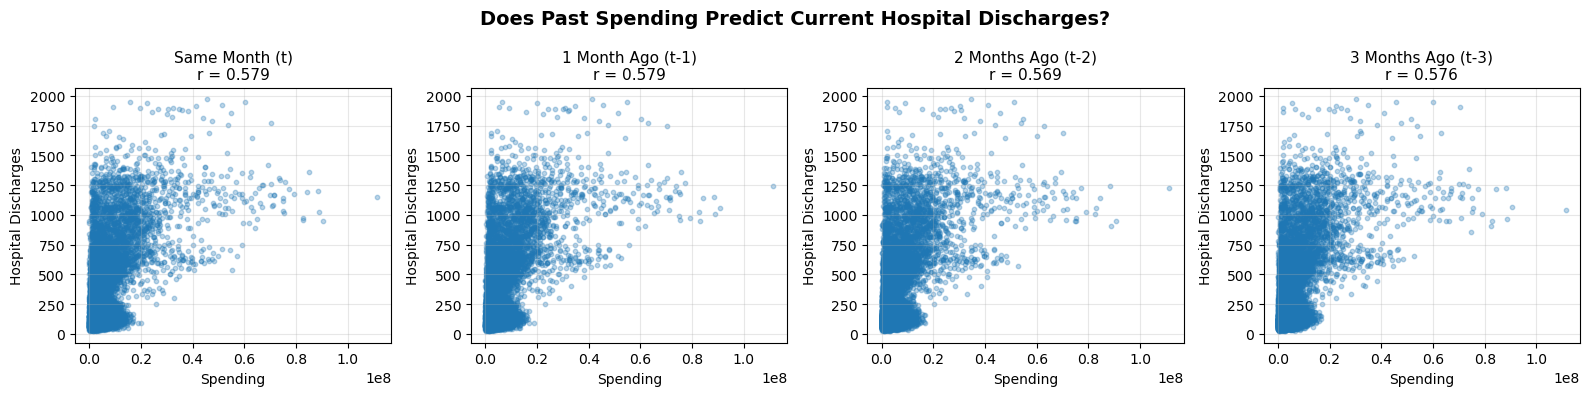

In [62]:
# Create lagged spending variables (spending from 1, 2, 3 months ago)
df_balanced = df_balanced.sort_values(['health_center_name', 'date'])

# Create lags by hospital
df_balanced['spending_lag1'] = df_balanced.groupby('health_center_name')['devengado_monthly'].shift(1)
df_balanced['spending_lag2'] = df_balanced.groupby('health_center_name')['devengado_monthly'].shift(2)
df_balanced['spending_lag3'] = df_balanced.groupby('health_center_name')['devengado_monthly'].shift(3)


outcomes = ['hospital_discharges', 'medical_visits_firstlevel', 'mortality_rate']

for outcome in outcomes:
    print(f"\n{outcome.upper()}:")
    
    # Current month correlation
    corr_t0 = df_balanced[['devengado_monthly', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t) → Outcome (t):     r = {corr_t0:.3f}")
    
    # 1 month lag
    corr_t1 = df_balanced[['spending_lag1', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t-1) → Outcome (t):   r = {corr_t1:.3f}")
    
    # 2 month lag
    corr_t2 = df_balanced[['spending_lag2', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t-2) → Outcome (t):   r = {corr_t2:.3f}")
    
    # 3 month lag
    corr_t3 = df_balanced[['spending_lag3', outcome]].corr().iloc[0, 1]
    print(f"  Spending (t-3) → Outcome (t):   r = {corr_t3:.3f}")

# Visualize for hospital discharges
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Does Past Spending Predict Current Hospital Discharges?', fontsize=14, fontweight='bold')

lags = [
    ('devengado_monthly', 'Same Month (t)'),
    ('spending_lag1', '1 Month Ago (t-1)'),
    ('spending_lag2', '2 Months Ago (t-2)'),
    ('spending_lag3', '3 Months Ago (t-3)')
]

for idx, (lag_var, title) in enumerate(lags):
    mask = df_balanced[[lag_var, 'hospital_discharges']].notna().all(axis=1)
    axes[idx].scatter(df_balanced.loc[mask, lag_var], 
                     df_balanced.loc[mask, 'hospital_discharges'], 
                     alpha=0.3, s=10)
    
    corr = df_balanced[[lag_var, 'hospital_discharges']].corr().iloc[0, 1]
    axes[idx].set_title(f'{title}\nr = {corr:.3f}', fontsize=11)
    axes[idx].set_xlabel('Spending', fontsize=10)
    axes[idx].set_ylabel('Hospital Discharges', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
# Los hospitales que gastan más gestionan más egresos
# pero es probable que se trate de causas simultáneas y no causales
# los r-values no muestran mayor relación 